# Machine Learning Assignment (Semester 252)

In [1]:
import os

# Repo information
GIT_REPO = "ML-Assignment"
GIT_PATH = f"https://github.com/phngan05/ML-Assignment.git"

# Check if the repository already exists, if not clone it. If it exists, pull the latest changes.
%cd /content
if not os.path.exists(GIT_REPO):
    !git clone {GIT_PATH}
    %cd {GIT_REPO}
else:
    %cd {GIT_REPO}
    !git pull origin main


/content
Cloning into 'ML-Assignment'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 183 (delta 73), reused 111 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (183/183), 22.59 MiB | 11.69 MiB/s, done.
Resolving deltas: 100% (73/73), done.
/content/ML-Assignment


In [2]:
!pip install -r requirements.txt --quiet

In [3]:
# Download the dataset
from modules import utils
utils.setup_data("blessondensil294/topic-modeling-for-research-articles")

--- Setting up Kaggle API and downloading data... ---
--- Data downloaded successfully into 'data' ---


In [4]:
# Use for check /content directory structure in VSCode
!ls -R /content

/content:
ML-Assignment  sample_data

/content/ML-Assignment:
data  modules  notebooks  README.md  requirements.txt

/content/ML-Assignment/data:
test.csv  train.csv

/content/ML-Assignment/modules:
eda.py	evaluation.py  model.py  preprocessing.py  __pycache__	utils.py

/content/ML-Assignment/modules/__pycache__:
utils.cpython-312.pyc

/content/ML-Assignment/notebooks:
main.ipynb

/content/sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [5]:
!cat /content/ML-Assignment/modules/preprocessing.py

import spacy

def lemma_data(df, column):
    nlp = spacy.load("en_core_web_sm", disable=['ner', 'parser'])
    processed_texts = []
    for doc in nlp.pipe(df[column].astype(str), batch_size=500, n_process=-1):
        tokens = [t.lemma_ for t in doc if t.pos_ in ['NOUN', 'ADJ', 'VERB']]
        processed_texts.append(" ".join(tokens))
    return processed_texts


In [6]:
import pandas as pd
df = pd.read_csv("/content/ML-Assignment/data/train.csv")
df.head()

,ID,TITLE,ABSTRACT,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance
0,1,Reconstructing Subject-Specific Effect Maps,Predictive models allow subject-specific inf...,1,0,0,0,0,0
1,2,Rotation Invariance Neural Network,Rotation invariance and translation invarian...,1,0,0,0,0,0
2,3,Spherical polyharmonics and Poisson kernels fo...,We introduce and develop the notion of spher...,0,0,1,0,0,0
3,4,A finite element approximation for the stochas...,The stochastic Landau--Lifshitz--Gilbert (LL...,0,0,1,0,0,0
4,5,Comparative study of Discrete Wavelet Transfor...,Fourier-transform infra-red (FTIR) spectra o...,1,0,0,1,0,0


## Exploratory Data Analysis

### Statistics & General Analysis

In [7]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20972 entries, 0 to 20971
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    20972 non-null  int64 
 1   TITLE                 20972 non-null  object
 2   ABSTRACT              20972 non-null  object
 3   Computer Science      20972 non-null  int64 
 4   Physics               20972 non-null  int64 
 5   Mathematics           20972 non-null  int64 
 6   Statistics            20972 non-null  int64 
 7   Quantitative Biology  20972 non-null  int64 
 8   Quantitative Finance  20972 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 1.4+ MB


(20972, 9)

In [8]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [9]:
label_columns = [
    "Computer Science",
    "Physics",
    "Mathematics",
    "Statistics",
    "Quantitative Biology",
    "Quantitative Finance"
]
df[label_columns].sum()

,0
Computer Science,8594
Physics,6013
Mathematics,5618
Statistics,5206
Quantitative Biology,587
Quantitative Finance,249


### Class Distribution Analysis

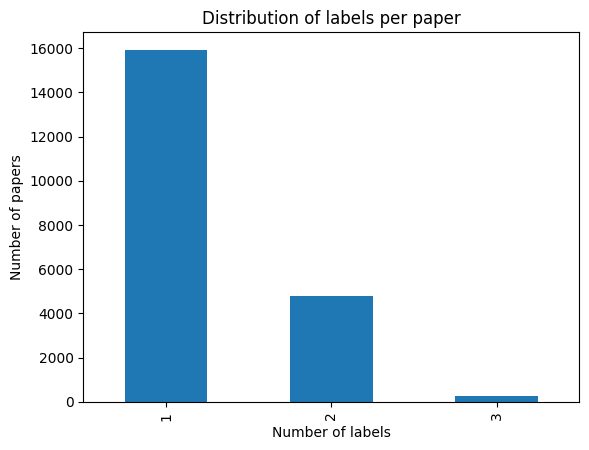

In [10]:
from modules.eda import visualize_labels_per_article
from modules.eda import visualize_corr_labels
visualize_labels_per_article(df, label_columns)

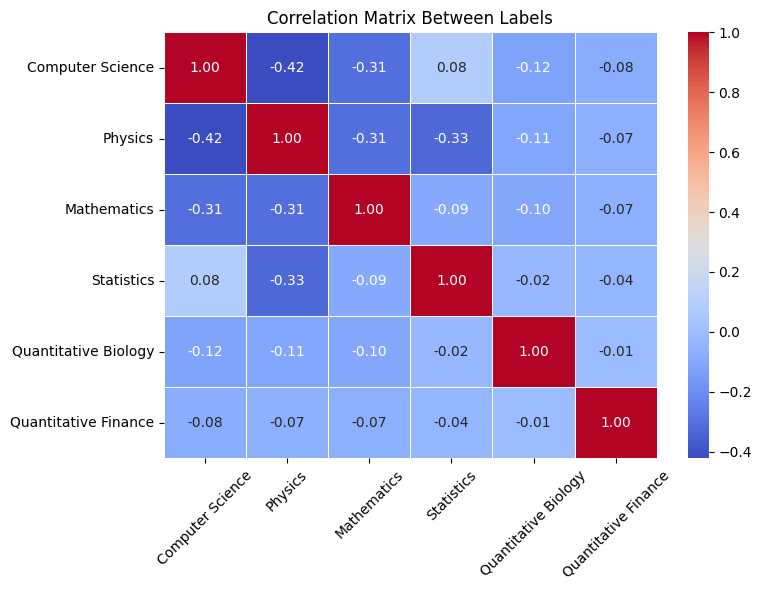

In [11]:
visualize_corr_labels(df, label_columns)

### Length Analysis

In [12]:
import nltk
from modules.eda import calculate_text_lengths
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

calculate_text_lengths(df, 'TITLE')
calculate_text_lengths(df, 'ABSTRACT')

df.info()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20972 entries, 0 to 20971
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             20972 non-null  int64  
 1   TITLE                          20972 non-null  object 
 2   ABSTRACT                       20972 non-null  object 
 3   Computer Science               20972 non-null  int64  
 4   Physics                        20972 non-null  int64  
 5   Mathematics                    20972 non-null  int64  
 6   Statistics                     20972 non-null  int64  
 7   Quantitative Biology           20972 non-null  int64  
 8   Quantitative Finance           20972 non-null  int64  
 9   num_labels                     20972 non-null  int64  
 10  TITLE_chars                    20972 non-null  int64  
 11  TITLE_words                    20972 non-null  int64  
 12  TITLE_mean_word_length         20972 non-null 

In [13]:
title_length_columns = ['TITLE_chars', 'TITLE_words', 'TITLE_mean_word_length', 'TITLE_mean_sentence_length']
abstract_length_columns = ['ABSTRACT_chars', 'ABSTRACT_words', 'ABSTRACT_mean_word_length', 'ABSTRACT_mean_sentence_length' ]

#### Title Analysis

In [14]:
df[title_length_columns].describe()

,TITLE_chars,TITLE_words,TITLE_mean_word_length,TITLE_mean_sentence_length
count,20972.000000,20972.000000,20972.000000,20972.000000
mean,72.897721,9.514972,7.812645,72.235310
std,26.128903,3.611493,1.246562,25.959505
min,7.000000,1.000000,3.500000,7.000000
25%,54.000000,7.000000,7.000000,54.000000
50%,71.000000,9.000000,7.714286,70.000000
75%,88.000000,12.000000,8.545455,88.000000
max,239.000000,40.000000,17.500000,239.000000


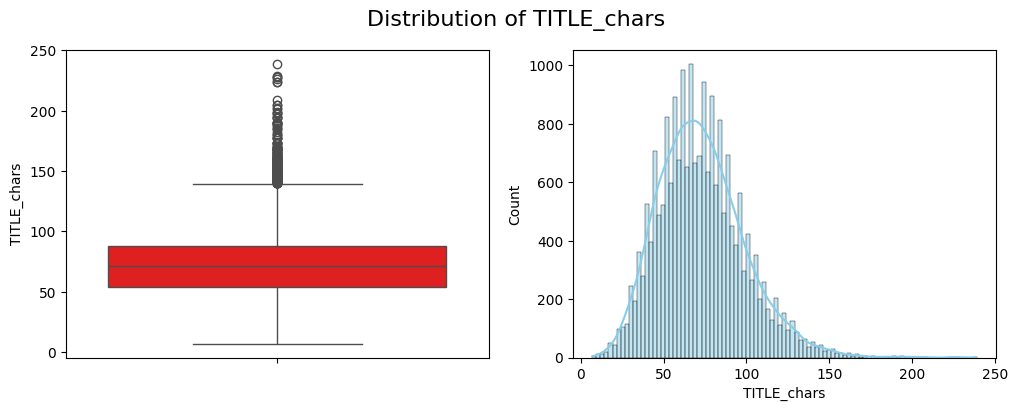

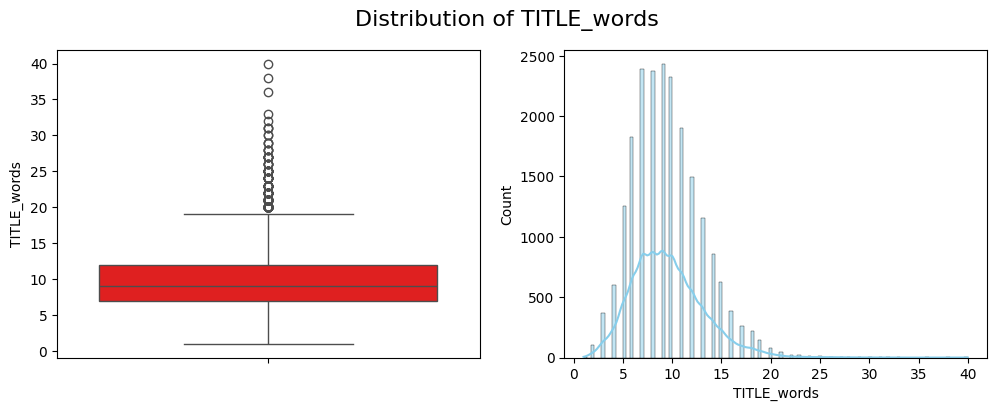

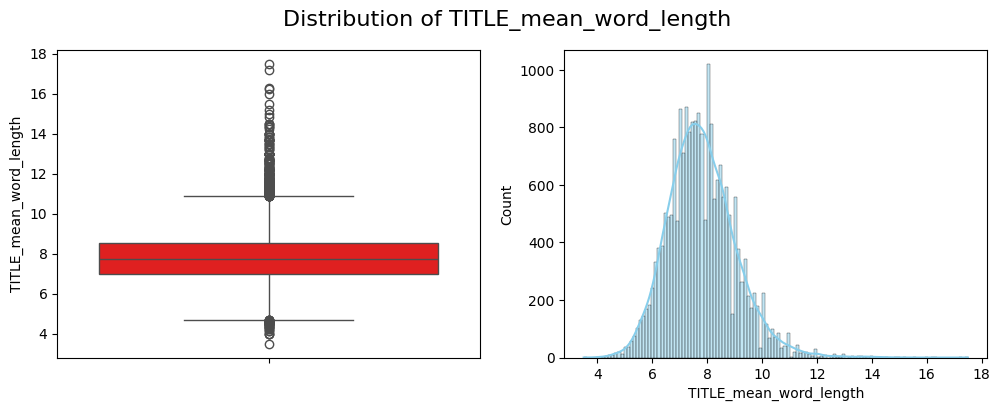

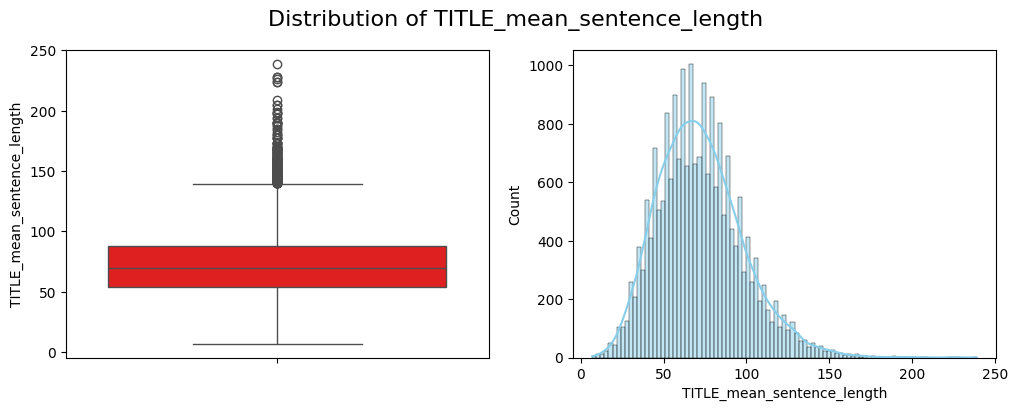

In [15]:
from modules.eda import visualize_text_length_distribution
for col in title_length_columns:
    visualize_text_length_distribution(df, col)

Titles are generally short and concise, with an average length of ~73 characters (~9–10 words). Most titles fall within 50–90 characters or 7–12 words, showing a relatively consistent structure. The distributions are slightly right-skewed, with several upper outliers representing unusually long or descriptive titles. The average word length (~7–8 characters) suggests the frequent use of technical or academic vocabulary.

#### Abstract Analysis

In [16]:
df[abstract_length_columns].describe()

,ABSTRACT_chars,ABSTRACT_words,ABSTRACT_mean_word_length,ABSTRACT_mean_sentence_length
count,20972.000000,20972.000000,20972.000000,20972.000000
mean,1009.103376,148.404873,6.821117,164.264092
std,408.641363,60.781306,0.466272,46.169121
min,7.000000,1.000000,4.052239,6.000000
25%,714.000000,104.000000,6.532609,137.000000
50%,989.000000,145.000000,6.806857,158.250000
75%,1290.000000,190.000000,7.090332,184.250000
max,2761.000000,449.000000,19.270270,1324.000000


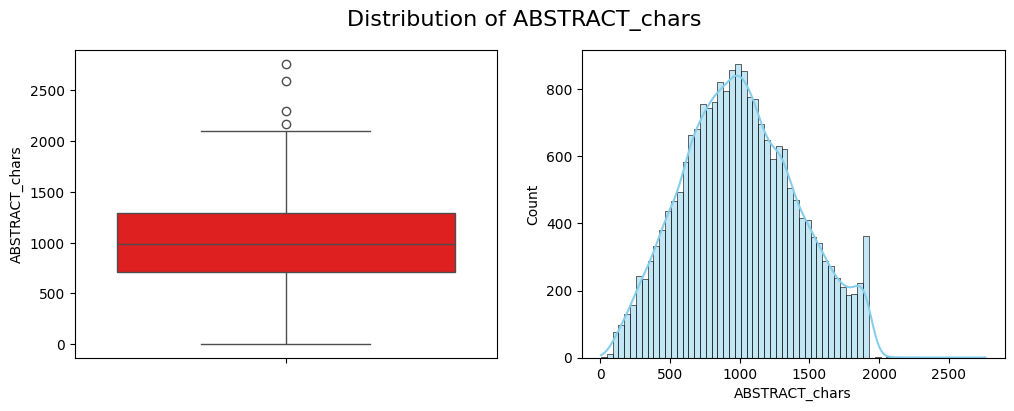

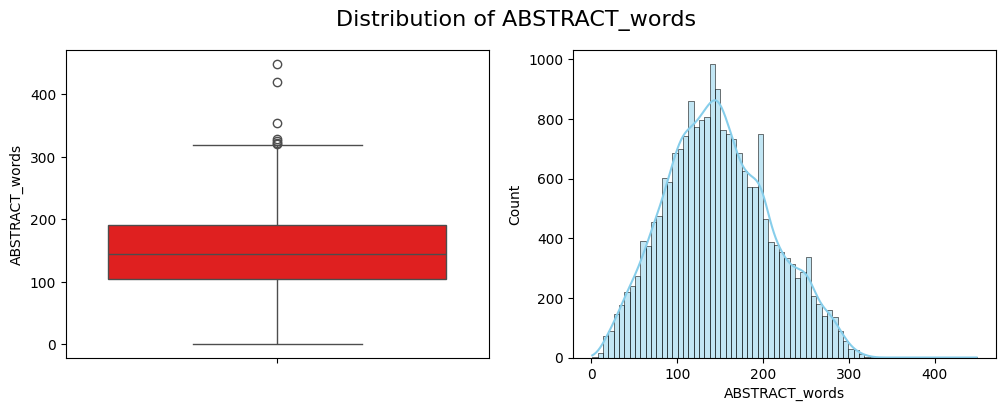

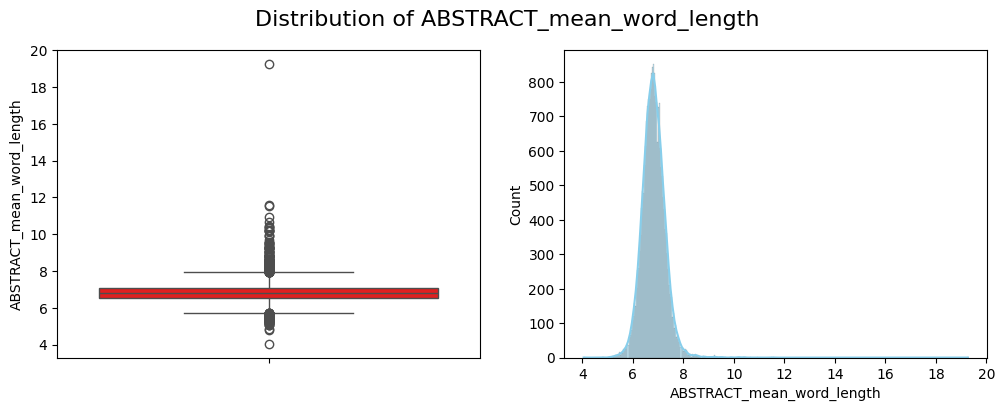

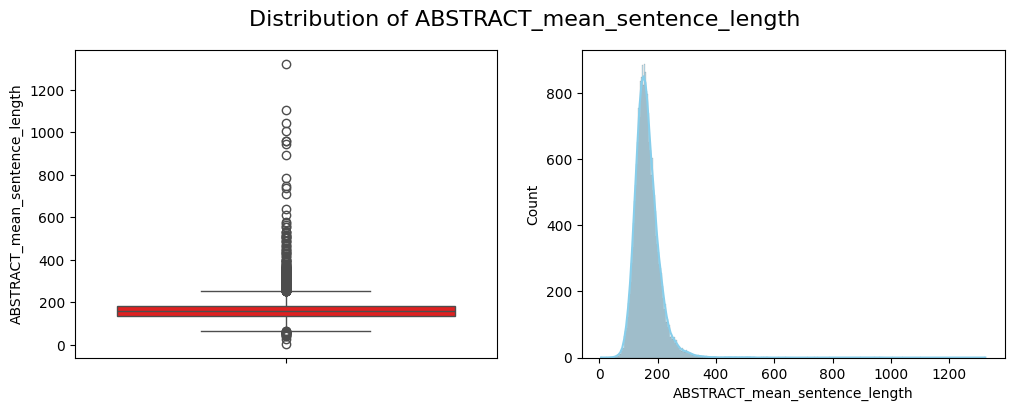

In [17]:
for col in abstract_length_columns:
    visualize_text_length_distribution(df, col)

Abstracts are significantly longer and more variable than titles, averaging ~1000 characters (~148 words). Most abstracts fall between 500–1500 characters or 100–200 words, which aligns with typical academic writing conventions. Sentence lengths are mostly concentrated around 100–200 characters, though some extreme outliers indicate either highly complex sentences or formatting inconsistencies. The average word length (~6–7 characters) also reflects the use of technical terminology.

  SO SÁNH ĐỘ DÀI TRUNG BÌNH THEO CHUYÊN NGÀNH
Chuyên ngành               Số bài  Title (từ)  Title (ký tự)  Abstract (từ)  Abstract (ký tự)
--------------------------------------------------------------------------------
Computer Science            8,594         9.0           69.9          159.1            1081.9
Physics                     6,013        10.7           80.7          161.4            1096.2
Mathematics                 5,618         9.0           68.2          113.7             769.8
Statistics                  5,206         8.9           70.5          155.6            1068.4
Quantitative Biology          587        10.6           81.8          177.7            1232.2
Quantitative Finance          249         9.7           73.0          140.6             946.0


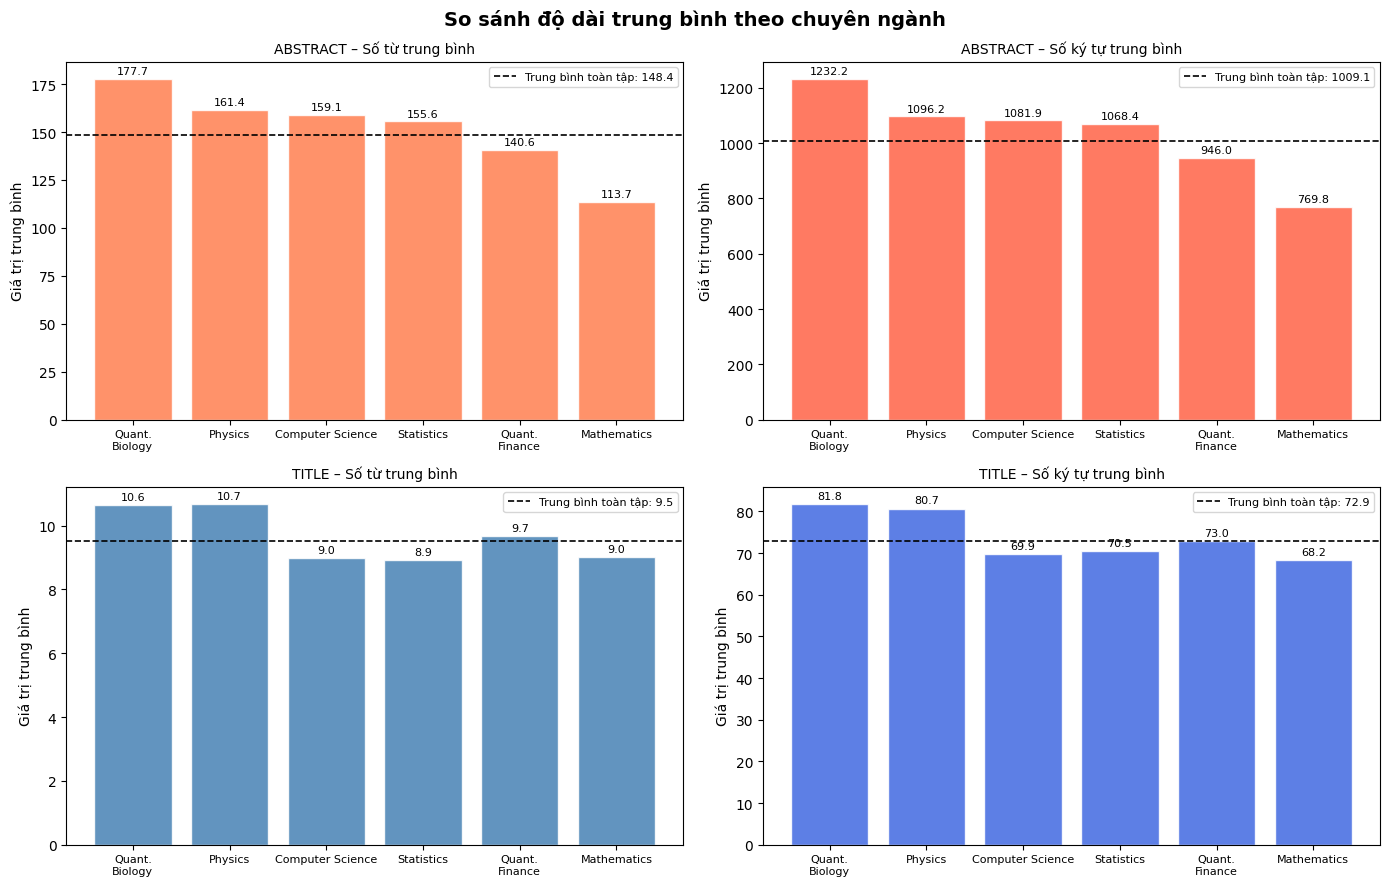


--- Nhận xét ---
Abstract dài nhất (số từ) : Quantitative Biology (177.7 từ/bài)
Abstract ngắn nhất (số từ): Mathematics (113.7 từ/bài)
Title dài nhất  (số từ)   : Physics (10.7 từ/bài)
Title ngắn nhất (số từ)   : Statistics (8.9 từ/bài)


In [18]:
import matplotlib.pyplot as plt
import numpy as np

label_cols = ["Computer Science", "Physics", "Mathematics",
              "Statistics", "Quantitative Biology", "Quantitative Finance"]

# Đảm bảo các cột độ dài đã tồn tại
if "abstract_word_len" not in df.columns:
    df["title_char_len"]    = df["TITLE"].str.len()
    df["abstract_char_len"] = df["ABSTRACT"].str.len()
    df["title_word_len"]    = df["TITLE"].str.split().str.len()
    df["abstract_word_len"] = df["ABSTRACT"].str.split().str.len()

# ============================================================
#  SO SÁNH ĐỘ DÀI TRUNG BÌNH THEO CHUYÊN NGÀNH
# ============================================================
print("=" * 80)
print("  SO SÁNH ĐỘ DÀI TRUNG BÌNH THEO CHUYÊN NGÀNH")
print("=" * 80)
print(f"{'Chuyên ngành':<25} {'Số bài':>7} "
      f"{'Title (từ)':>11} {'Title (ký tự)':>14} "
      f"{'Abstract (từ)':>14} {'Abstract (ký tự)':>17}")
print("-" * 80)

summary = []
for lbl in label_cols:
    sub = df[df[lbl] == 1]
    summary.append({
        "label"       : lbl,
        "n"           : len(sub),
        "title_words" : sub["title_word_len"].mean(),
        "title_chars" : sub["title_char_len"].mean(),
        "abs_words"   : sub["abstract_word_len"].mean(),
        "abs_chars"   : sub["abstract_char_len"].mean(),
    })
    print(f"{lbl:<25} {len(sub):>7,} "
          f"{sub['title_word_len'].mean():>11.1f} {sub['title_char_len'].mean():>14.1f} "
          f"{sub['abstract_word_len'].mean():>14.1f} {sub['abstract_char_len'].mean():>17.1f}")

# --- Vẽ biểu đồ ---
labels_sorted = [s["label"] for s in sorted(summary, key=lambda x: x["abs_words"], reverse=True)]
abs_words  = [next(s["abs_words"]  for s in summary if s["label"] == l) for l in labels_sorted]
abs_chars  = [next(s["abs_chars"]  for s in summary if s["label"] == l) for l in labels_sorted]
title_words = [next(s["title_words"] for s in summary if s["label"] == l) for l in labels_sorted]
title_chars = [next(s["title_chars"] for s in summary if s["label"] == l) for l in labels_sorted]

x = np.arange(len(labels_sorted))
short_labels = [l.replace("Quantitative ", "Quant.\n") for l in labels_sorted]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("So sánh độ dài trung bình theo chuyên ngành", fontsize=14, fontweight="bold")

datasets = [
    (axes[0, 0], abs_words,   "ABSTRACT – Số từ trung bình",       "coral"),
    (axes[0, 1], abs_chars,   "ABSTRACT – Số ký tự trung bình",    "tomato"),
    (axes[1, 0], title_words, "TITLE – Số từ trung bình",          "steelblue"),
    (axes[1, 1], title_chars, "TITLE – Số ký tự trung bình",       "royalblue"),
]

for ax, values, title, color in datasets:
    bars = ax.bar(x, values, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=8)
    ax.set_ylabel("Giá trị trung bình")
    # Đường trung bình toàn tập
    if "ABSTRACT" in title and "từ" in title:
        overall_val = df["abstract_word_len"].mean()
    elif "ABSTRACT" in title:
        overall_val = df["abstract_char_len"].mean()
    elif "TITLE" in title and "từ" in title:
        overall_val = df["title_word_len"].mean()
    else:
        overall_val = df["title_char_len"].mean()

    ax.axhline(overall_val, color="black", linestyle="--", linewidth=1.2,
               label=f"Trung bình toàn tập: {overall_val:.1f}")
    ax.legend(fontsize=8)
    for bar_rect, val in zip(bars, values):
        ax.text(bar_rect.get_x() + bar_rect.get_width() / 2,
                bar_rect.get_height() + overall_val * 0.01,
                f"{val:.1f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Nhận xét nổi bật
print("\n--- Nhận xét ---")
max_abs = max(summary, key=lambda x: x["abs_words"])
min_abs = min(summary, key=lambda x: x["abs_words"])
max_title = max(summary, key=lambda x: x["title_words"])
min_title = min(summary, key=lambda x: x["title_words"])
print(f"Abstract dài nhất (số từ) : {max_abs['label']} ({max_abs['abs_words']:.1f} từ/bài)")
print(f"Abstract ngắn nhất (số từ): {min_abs['label']} ({min_abs['abs_words']:.1f} từ/bài)")
print(f"Title dài nhất  (số từ)   : {max_title['label']} ({max_title['title_words']:.1f} từ/bài)")
print(f"Title ngắn nhất (số từ)   : {min_title['label']} ({min_title['title_words']:.1f} từ/bài)")


## Preprocessing

### 1. Outlier Removal

Dựa trên EDA (IQR × 1.5):
- **ABSTRACT_words**: lower fence ≈ −25 → dùng ngưỡng thực tế **20 từ**; upper fence ≈ 319 → dùng **320 từ**
- **TITLE_words**: lower fence ≈ −0.5 → dùng ngưỡng thực tế **3 từ**; upper fence ≈ 19.5 → dùng **20 từ**

Ngưỡng dưới loại bỏ các bài abstract gần như rỗng (vd: *"Yes."*), ngưỡng trên loại bỏ các bài có độ dài bất thường.

In [19]:
print(f"Số dòng trước khi loại outlier: {len(df):,}")

# Ngưỡng xác định từ EDA (IQR × 1.5)
ABSTRACT_MIN_WORDS = 20
ABSTRACT_MAX_WORDS = 320
TITLE_MIN_WORDS    = 3
TITLE_MAX_WORDS    = 20

mask = (
    (df["ABSTRACT_words"] >= ABSTRACT_MIN_WORDS) &
    (df["ABSTRACT_words"] <= ABSTRACT_MAX_WORDS) &
    (df["TITLE_words"]    >= TITLE_MIN_WORDS)    &
    (df["TITLE_words"]    <= TITLE_MAX_WORDS)
)

df_clean = df[mask].reset_index(drop=True)

print(f"Số dòng sau khi loại outlier : {len(df_clean):,}")
print(f"Số dòng bị loại              : {len(df) - len(df_clean):,} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")
print()
df_clean[["ABSTRACT_words", "TITLE_words"]].describe().round(1)

Số dòng trước khi loại outlier: 20,972
Số dòng sau khi loại outlier : 20,625
Số dòng bị loại              : 347 (1.65%)



,ABSTRACT_words,TITLE_words
count,20625.0,20625.0
mean,148.8,9.5
std,60.0,3.4
min,20.0,3.0
25%,105.0,7.0
50%,145.0,9.0
75%,190.0,12.0
max,319.0,20.0


### 2. Chuyển về chữ thường


In [20]:
# Ghép TITLE + ABSTRACT thành một cột text duy nhất
df_clean["text"] = df_clean["TITLE"] + " " + df_clean["ABSTRACT"]

# Chuyển về chữ thường
df_clean["text"] = df_clean["text"].str.lower()

# Kiểm tra
print("Trước:")
print(df_clean["TITLE"].iloc[0])
print("\nSau (text):")
print(df_clean["text"].iloc[0][:200])

Trước:
Reconstructing Subject-Specific Effect Maps

Sau (text):
reconstructing subject-specific effect maps   predictive models allow subject-specific inference when analyzing disease
related alterations in neuroimaging data. given a subject's data, inference can



### 3. Loại bỏ ký tự đặc biệt, dấu câu, số và khoảng trắng thừa


In [21]:
import re

def remove_noise(text: str) -> str:
    # Xóa ký hiệu LaTeX: $...$  $$...$$  \command{...}  \command
    text = re.sub(r'\$\$?.*?\$\$?', ' ', text, flags=re.DOTALL)
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', ' ', text)
    text = re.sub(r'\\[a-zA-Z]+', ' ', text)

    # Xóa URL
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Xóa số
    text = re.sub(r'\d+', ' ', text)

    # Xóa ký tự đặc biệt và dấu câu (chỉ giữ chữ cái và khoảng trắng)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_clean["text"] = df_clean["text"].apply(remove_noise)

# Kiểm tra
print("Sau khi loại ký tự đặc biệt / số / khoảng trắng thừa:")
print(df_clean["text"].iloc[0][:300])


Sau khi loại ký tự đặc biệt / số / khoảng trắng thừa:
reconstructing subject specific effect maps predictive models allow subject specific inference when analyzing disease related alterations in neuroimaging data given a subject s data inference can be made at two levels global i e identifiying condition presence for the subject and local i e detecting


### 4. Loại bỏ Stopwords Dùng NLTK English stopwords (179 từ) thay vì hardcode

In [22]:
import nltk
from nltk.corpus import stopwords

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords")

STOPWORDS = set(stopwords.words("english"))

def remove_stopwords(text: str) -> str:
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return " ".join(tokens)

df_clean["text_clean"] = df_clean["text"].apply(remove_stopwords)

# Kiểm tra
print(f"Số từ trung bình trước khi loại stopwords: {df_clean['text'].str.split().str.len().mean():.1f}")
print(f"Số từ trung bình sau khi loại stopwords  : {df_clean['text_clean'].str.split().str.len().mean():.1f}")
print()
print("Ví dụ sau khi loại stopwords:")
print(df_clean["text_clean"].iloc[0][:300])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Số từ trung bình trước khi loại stopwords: 160.0
Số từ trung bình sau khi loại stopwords  : 97.0

Ví dụ sau khi loại stopwords:
reconstructing subject specific effect maps predictive models allow subject specific inference analyzing disease related alterations neuroimaging data given subject data inference made two levels global identifiying condition presence subject local detecting condition effect individual measurement e


### 5. Top 20 Từ Xuất Hiện Nhiều Nhất

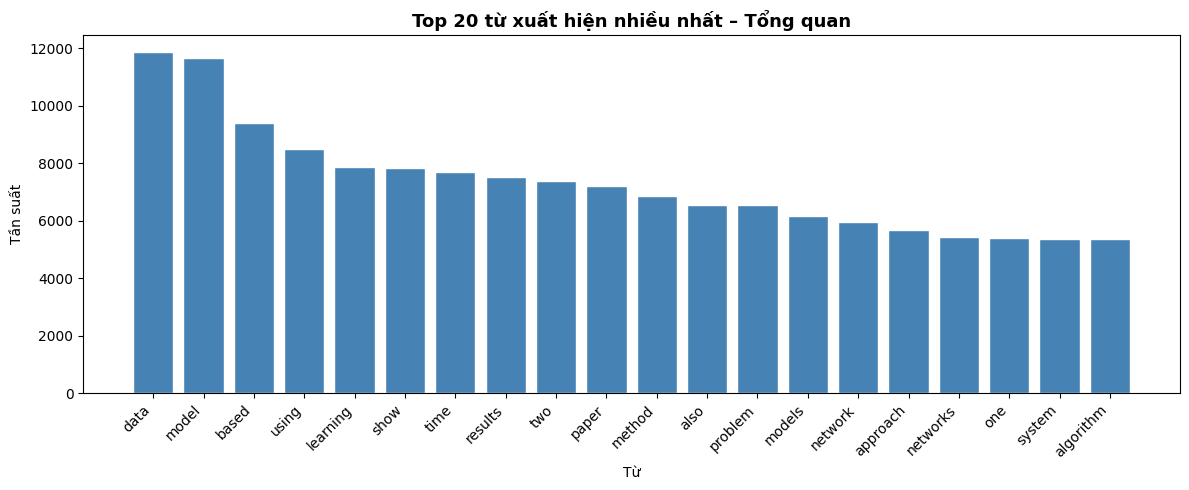

Từ                     Tần suất
--------------------------------
data                     11,850
model                    11,646
based                     9,400
using                     8,503
learning                  7,873
show                      7,827
time                      7,701
results                   7,503
two                       7,386
paper                     7,211
method                    6,851
also                      6,560
problem                   6,556
models                    6,165
network                   5,940
approach                  5,685
networks                  5,440
one                       5,384
system                    5,378
algorithm                 5,368


In [23]:
from collections import Counter
import matplotlib.pyplot as plt

# --- Tổng quan ---
all_words = " ".join(df_clean["text_clean"]).split()
top20_all = Counter(all_words).most_common(20)
words_all, counts_all = zip(*top20_all)

plt.figure(figsize=(12, 5))
plt.bar(words_all, counts_all, color="steelblue", edgecolor="white")
plt.title("Top 20 từ xuất hiện nhiều nhất – Tổng quan", fontsize=13, fontweight="bold")
plt.xlabel("Từ")
plt.ylabel("Tần suất")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"{'Từ':<20} {'Tần suất':>10}")
print("-" * 32)
for word, cnt in top20_all:
    print(f"{word:<20} {cnt:>10,}")


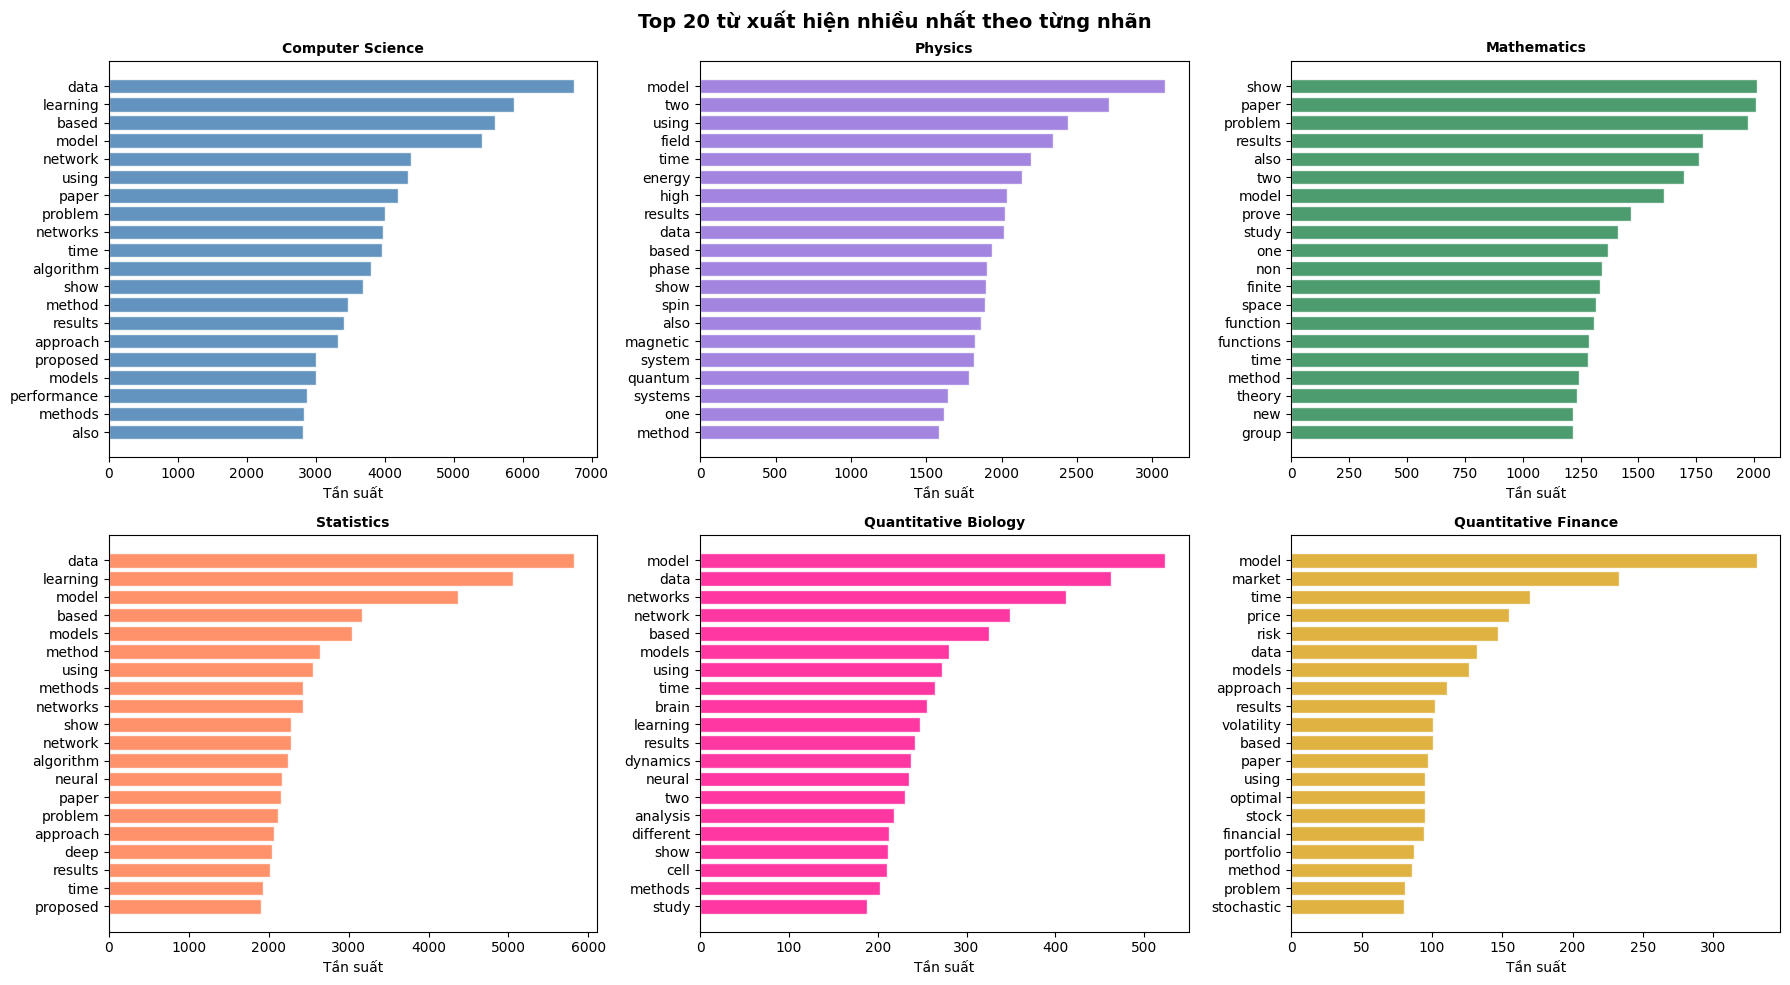

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Top 20 từ xuất hiện nhiều nhất theo từng nhãn", fontsize=14, fontweight="bold")

colors = ["steelblue", "mediumpurple", "seagreen", "coral", "deeppink", "goldenrod"]

for ax, label, color in zip(axes.flatten(), label_columns, colors):
    words_label = " ".join(df_clean[df_clean[label] == 1]["text_clean"]).split()
    top20 = Counter(words_label).most_common(20)
    if not top20:
        continue
    words, counts = zip(*top20)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.85, edgecolor="white")
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("Tần suất")

plt.tight_layout()
plt.show()


### 6. WordCloud theo Từng Nhãn

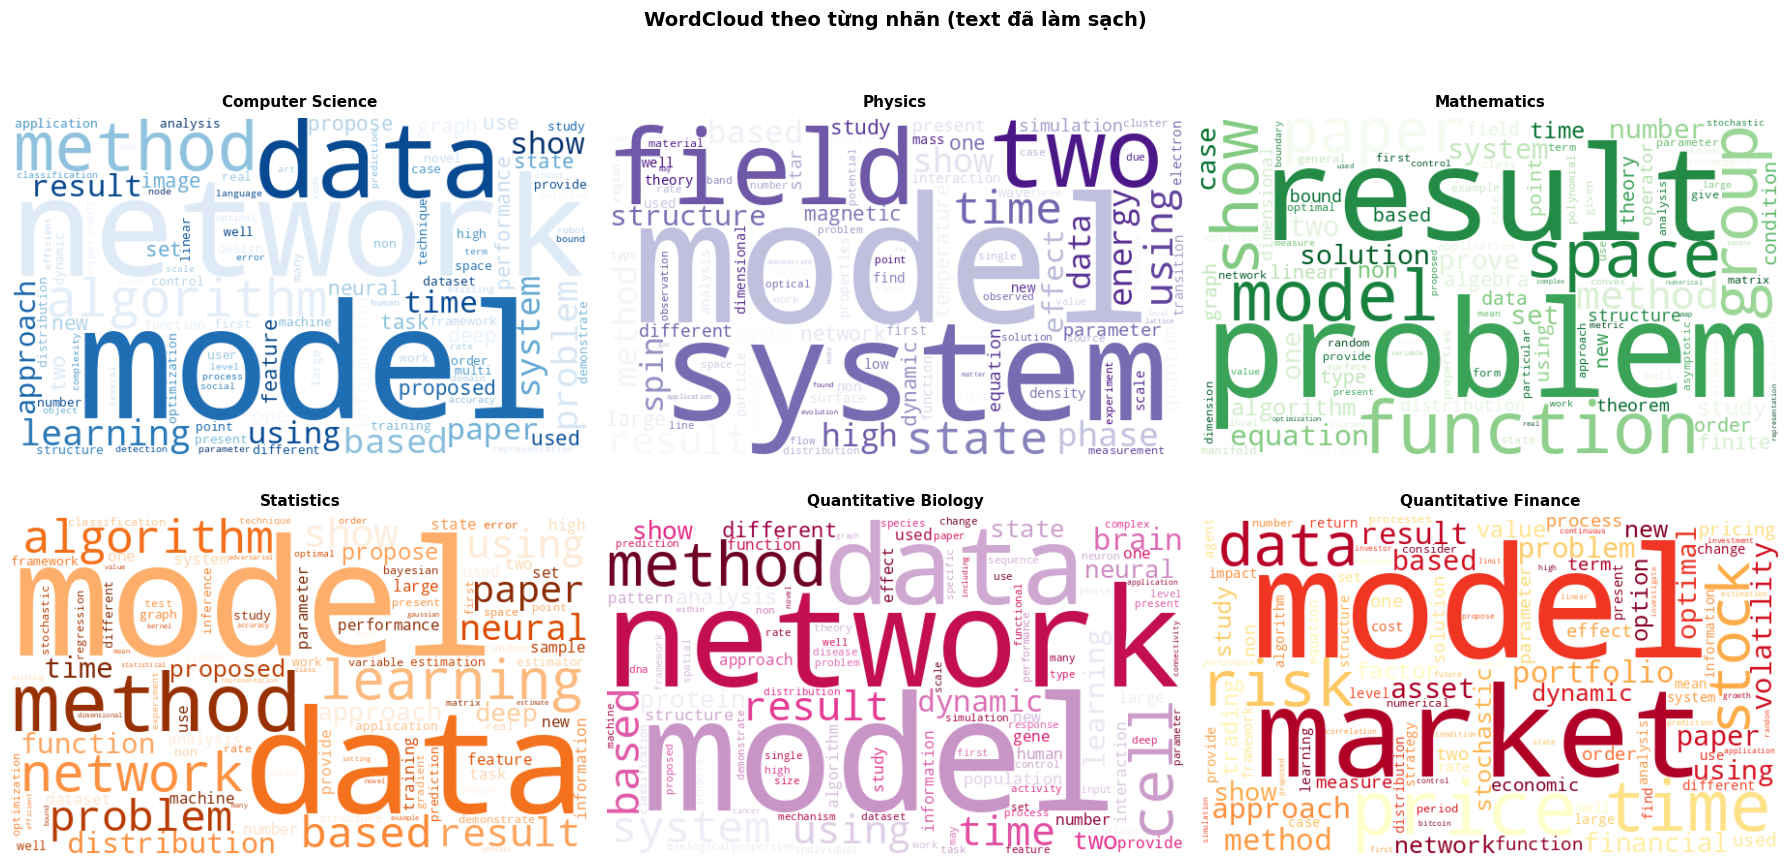

In [25]:
!pip install wordcloud --quiet

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def make_wordcloud(text, title, ax, colormap="viridis"):
    wc = WordCloud(
        width=600, height=350,
        background_color="white",
        max_words=100,
        colormap=colormap,
        collocations=False,
    ).generate(text if text.strip() else "no data")
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.axis("off")

palette = ["Blues_r", "Purples_r", "Greens_r", "Oranges_r", "PuRd_r", "YlOrRd_r"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle("WordCloud theo từng nhãn (text đã làm sạch)", fontsize=14, fontweight="bold", y=1.01)

for ax, label, cmap in zip(axes.flatten(), label_columns, palette):
    text = " ".join(df_clean[df_clean[label] == 1]["text_clean"].dropna())
    make_wordcloud(text, label, ax, cmap)

plt.tight_layout()
plt.show()


### 7. Lemmatization

In [26]:
# Take about 3 minutes :((
from modules import preprocessing

df_clean['lemma_text'] = preprocessing.lemma_data(df_clean, 'text_clean')

In [27]:
print("========== BEFORE LEMMATIZATION ==========")
print(df_clean['text_clean'].head())

print("\n\n========== AFTER LEMMATIZATION ==========")

print(df_clean['lemma_text'].head())


========== BEFORE LEMMATIZATION ==========
0    reconstructing subject specific effect maps pr...
1    rotation invariance neural network rotation in...
2    spherical polyharmonics poisson kernels polyha...
3    finite element approximation stochastic maxwel...
4    comparative study discrete wavelet transforms ...
Name: text_clean, dtype: object


========== AFTER LEMMATIZATION ==========
0    reconstruct subject specific effect map predic...
1    rotation invariance neural network rotation in...
2    spherical polyharmonic poisson kernel function...
3    element approximation stochastic stochastic co...
4    comparative study discrete wavelet transform w...
Name: lemma_text, dtype: object


In [28]:
print(f"Số từ trung bình trước lemmatization  : {df_clean['text_clean'].str.split().str.len().mean():.1f}")
print(f"Số từ trung bình sau lemmatization  : {df_clean['lemma_text'].str.split().str.len().mean():.1f}")

Số từ trung bình trước lemmatization  : 97.0
Số từ trung bình sau lemmatization  : 85.6


### 8. Bi-gram Analysis

/content/ML-Assignment/modules/eda.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=top_ngrams, palette='viridis', ax=axes[i])
/content/ML-Assignment/modules/eda.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=top_ngrams, palette='viridis', ax=axes[i])
/content/ML-Assignment/modules/eda.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=top_ngrams, palette='viridis', ax=axes[i])
/content/ML-Assignment/modules/eda.py:102: FutureWarnin

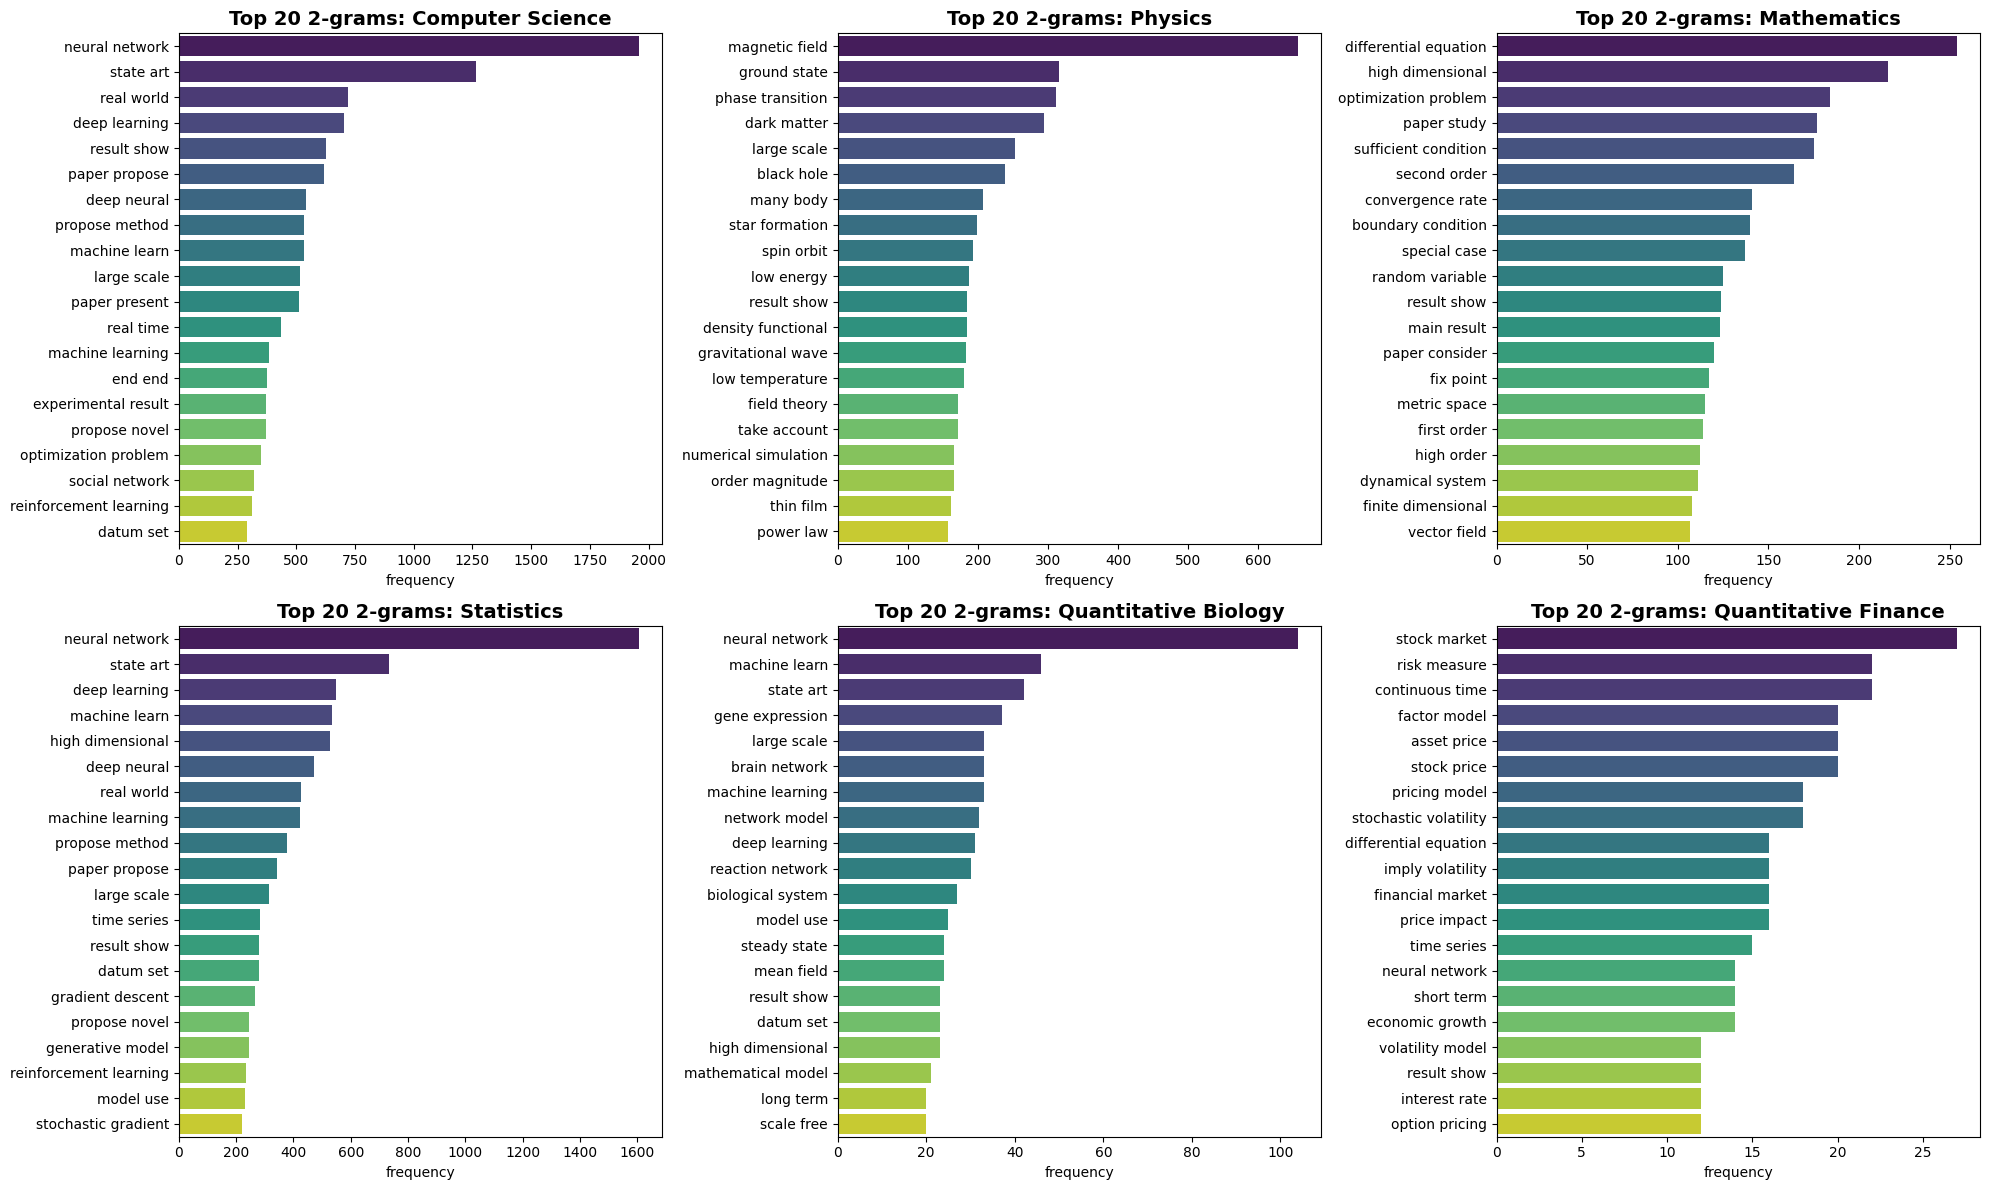

In [29]:
from modules import eda
labels = ['Computer Science', 'Physics', 'Mathematics', 'Statistics', 'Quantitative Biology', 'Quantitative Finance']

eda.visualize_ngram(df_clean, labels, 2)

/content/ML-Assignment/modules/eda.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=top_ngrams, palette='viridis', ax=axes[i])
/content/ML-Assignment/modules/eda.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=top_ngrams, palette='viridis', ax=axes[i])
/content/ML-Assignment/modules/eda.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=top_ngrams, palette='viridis', ax=axes[i])
/content/ML-Assignment/modules/eda.py:102: FutureWarnin

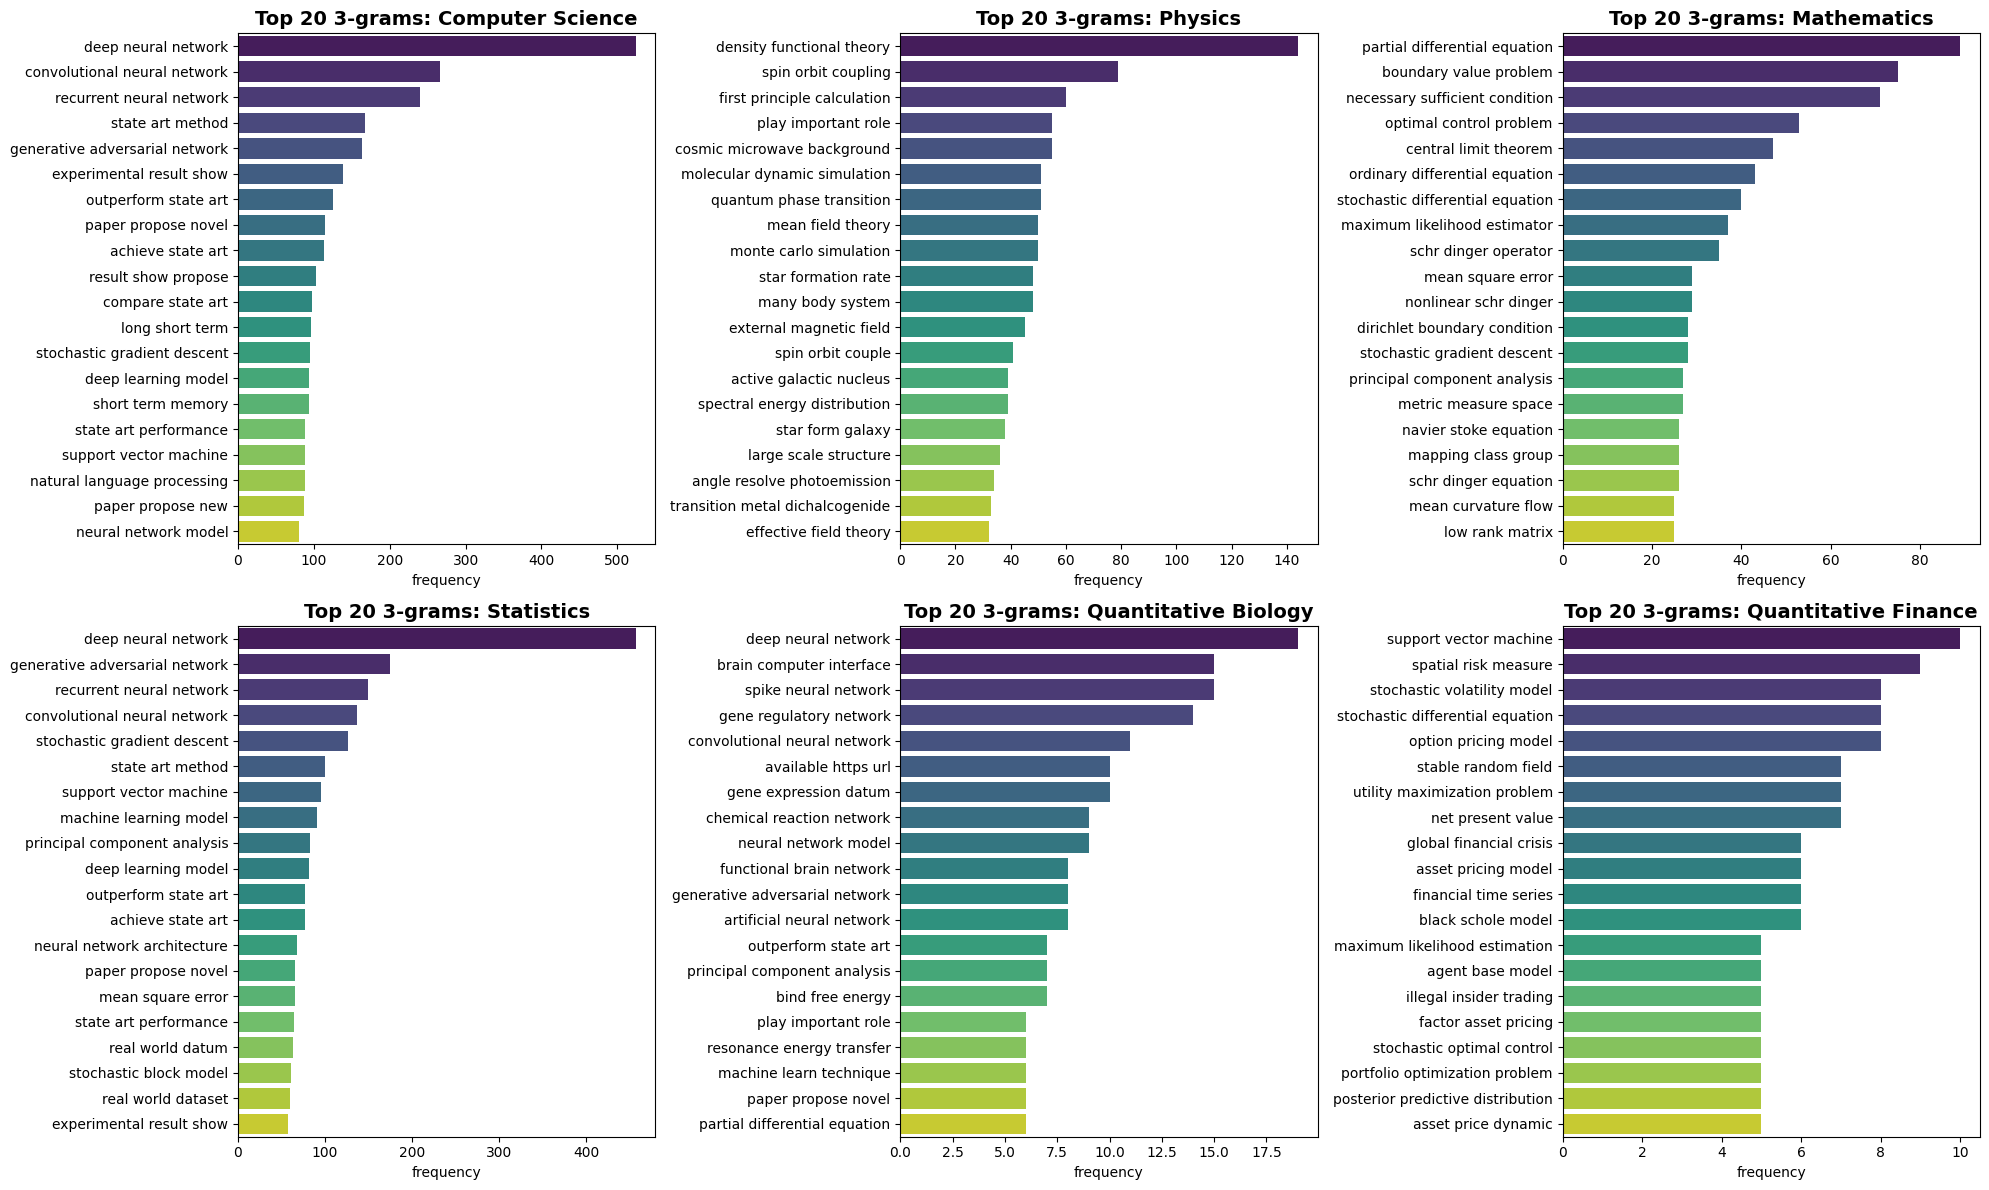

In [30]:
eda.visualize_ngram(df_clean, labels, 3)


In [31]:
# ============================================================
# FEATURE EXTRACTION
# ============================================================
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.corpus import stopwords
import numpy as np
import pickle
from scipy.sparse import save_npz

# Custom stopwords = NLTK stopwords + domain stopwords
custom_stopwords = set(stopwords.words("english"))
custom_stopwords.update({
    "use", "used", "using", "show", "shown", "result", "results",
    "method", "methods", "approach", "approaches", "based", "paper",
    "propose", "proposed", "study", "studies"
})

# Chọn cột text sau preprocessing
if 'lemma_text' in df_clean.columns:
    text_column = 'lemma_text'


X = df_clean[text_column]
y = df_clean[['Computer Science', 'Physics', 'Mathematics', 'Statistics',
              'Quantitative Biology', 'Quantitative Finance']]

print(f"Data shape: {len(X):,} samples, {y.shape[1]} labels")
print(f"Using column: '{text_column}'")

Data shape: 20,625 samples, 6 labels
Using column: 'lemma_text'


In [32]:
# ============================================================
# 1. BAG OF WORDS (CountVectorizer)
# ============================================================
count_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words=list(custom_stopwords)
)

X_bow = count_vectorizer.fit_transform(X)

print("BAG OF WORDS")
print("="*60)
print(f"Shape: {X_bow.shape}")
print(f"Sparsity: {(1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])) * 100:.2f}%")



BAG OF WORDS
Shape: (20625, 5000)
Sparsity: 98.89%


In [33]:
# ============================================================
# 2. TF-IDF - IMPROVED
# ============================================================
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    stop_words=list(custom_stopwords)
)

X_tfidf = tfidf_vectorizer.fit_transform(X)

print("TF-IDF")
print("="*60)
print(f"Shape: {X_tfidf.shape}")
print(f"Sparsity: {(1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100:.2f}%")



TF-IDF
Shape: (20625, 5000)
Sparsity: 98.89%


In [34]:

feature_names_bow = count_vectorizer.get_feature_names_out()
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()

# So sánh giữa 2 phương pháp feature extraction
doc_idx = 0
print(f"Document #{doc_idx}: {df_clean['TITLE'].iloc[doc_idx]}\n")

# ===== BoW =====
bow_vec = X_bow[doc_idx].toarray().flatten()
bow_top = bow_vec.argsort()[-5:][::-1]

print("BoW - Top 5:")
count = 1
for idx in bow_top:
    if bow_vec[idx] > 0:
        print(f"  {count}. {feature_names_bow[idx]:20s} → {bow_vec[idx]:.0f}")
        count += 1

# ===== TF-IDF =====
tfidf_vec = X_tfidf[doc_idx].toarray().flatten()
tfidf_top = tfidf_vec.argsort()[-5:][::-1]

print("\nTF-IDF - Top 5:")
count = 1
for idx in tfidf_top:
    if tfidf_vec[idx] > 0:
        print(f"  {count}. {feature_names_tfidf[idx]:20s} → {tfidf_vec[idx]:.4f}")
        count += 1

Document #0: Reconstructing Subject-Specific Effect Maps

BoW - Top 5:
  1. subject              → 8
  2. datum                → 7
  3. specific             → 6
  4. detection            → 5
  5. classifier           → 4

TF-IDF - Top 5:
  1. subject              → 0.2396
  2. alzheimer            → 0.2063
  3. neuroimage           → 0.2054
  4. classifier           → 0.1943
  5. disease              → 0.1879


/tmp/ipykernel_3923/3460729734.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette='viridis', ax=axes[0])


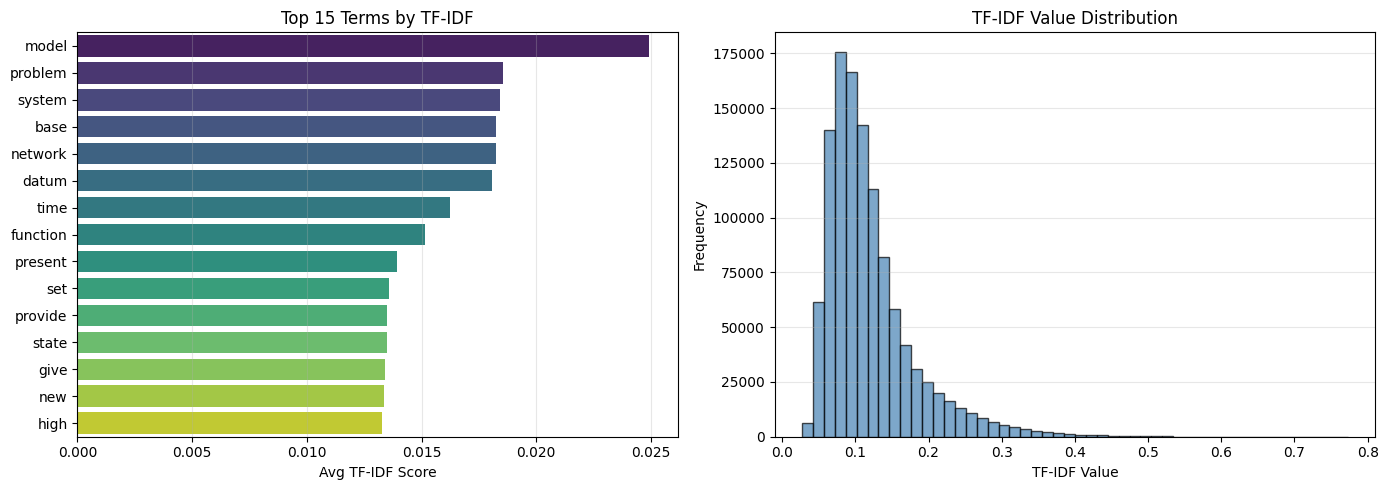

TF-IDF stats: min=0.0271, max=0.7730, mean=0.1195


In [35]:
# ============================================================
# VISUALIZATION: TF-IDF Distribution
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 terms
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).flatten()
top_15 = mean_tfidf.argsort()[-15:][::-1]
top_words = [feature_names_tfidf[i] for i in top_15]
top_scores = [mean_tfidf[i] for i in top_15]

sns.barplot(x=top_scores, y=top_words, palette='viridis', ax=axes[0])
axes[0].set_xlabel('Avg TF-IDF Score')
axes[0].set_title('Top 15 Terms by TF-IDF')
axes[0].grid(axis='x', alpha=0.3)

# Distribution
non_zero = X_tfidf.data
axes[1].hist(non_zero, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('TF-IDF Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('TF-IDF Value Distribution')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"TF-IDF stats: min={non_zero.min():.4f}, max={non_zero.max():.4f}, mean={non_zero.mean():.4f}")

In [36]:
# ============================================================
# SAVE RESULTS
# ============================================================
# Save BoW
with open('bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(count_vectorizer, f)
save_npz('X_bow.npz', X_bow)

# Save TF-IDF (recommended for training)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
save_npz('X_tfidf.npz', X_tfidf)

# Save labels
y.to_csv('y_labels.csv', index=False)

print("✓ Saved:")
print("  - bow_vectorizer.pkl, X_bow.npz")
print("  - tfidf_vectorizer.pkl, X_tfidf.npz")
print("  - y_labels.csv")
print(f"\nFeatures shape: {X_tfidf.shape}")
print(f"Labels shape: {y.shape}")
print("\n→ Ready for model training!")

✓ Saved:
  - bow_vectorizer.pkl, X_bow.npz
  - tfidf_vectorizer.pkl, X_tfidf.npz
  - y_labels.csv

Features shape: (20625, 5000)
Labels shape: (20625, 6)

→ Ready for model training!


## 🚀 Giai đoạn: Deep Learning Workflow
---
**Mục tiêu:** Sử dụng sức mạnh của Deep Learning để biến đổi dữ liệu văn bản thành các vector đặc trưng (Embeddings) chất lượng cao.

**Các bước thực hiện:**
1. **Feature Extraction:** Sử dụng Pre-trained Model (SciBERT) để lấy vector đại diện.
2. **Storage:** Lưu trữ đặc trưng dưới định dạng `.npy` để tối ưu bộ nhớ.
3. **Classification:** Huấn luyện các bộ phân loại dựa trên đặc trưng đã trích xuất.

---
*Lưu ý: Cần chuyển Runtime sang **GPU** để tăng tốc quá trình này.*


In [37]:
#lấy lại kết quả EDA để lựa làm giới hạn cho mô hình BERT (xử lí được tối đa 512 từ)

ABSTRACT_MIN_WORDS = 20
ABSTRACT_MAX_WORDS = 320
TITLE_MIN_WORDS    = 3
TITLE_MAX_WORDS    = 20

mask = (
    (df["ABSTRACT_words"] >= ABSTRACT_MIN_WORDS) &
    (df["ABSTRACT_words"] <= ABSTRACT_MAX_WORDS) &
    (df["TITLE_words"]    >= TITLE_MIN_WORDS)    &
    (df["TITLE_words"]    <= TITLE_MAX_WORDS)
)

df_bert = df[mask].reset_index(drop=True)

df_bert['combined_text'] = df_bert['TITLE'] + " [SEP] " + df_bert['ABSTRACT']
df_bert['combined_text'].head()

,combined_text
0,Reconstructing Subject-Specific Effect Maps [S...
1,Rotation Invariance Neural Network [SEP] Rot...
2,Spherical polyharmonics and Poisson kernels fo...
3,A finite element approximation for the stochas...
4,Comparative study of Discrete Wavelet Transfor...


In [38]:
!pip install transformers torch

In [39]:
import torch
import numpy as np
import gc # Để giải phóng bộ nhớ
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# 1. Cấu hình
model_names = ['bert-base-uncased', 'allenai/scibert_scivocab_uncased']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
max_length = 256 # Độ dài bạn đã tính toán từ bước EDA

# 2. Tải Model & Tokenizer


def extract_embeddings(text_list, model_id, batch_size=128):
    # Tải tokenizer và model
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(device)
    model.eval()

    all_embeddings = []
    # Chia nhỏ dữ liệu để tránh tràn RAM/GPU
    for i in tqdm(range(0, len(text_list), batch_size)):
        batch_texts = text_list[i : i + batch_size]

        # Tokenize
        inputs = tokenizer(batch_texts, padding=True, truncation=True,
                           max_length=max_length, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)

            # Lấy vector của [CLS] token (đại diện cho cả câu)
            # outputs.last_hidden_state có dạng [batch_size, seq_len, 768]
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_embeddings)

    # Giải phóng GPU/RAM sau khi xong mỗi model
    del model
    del tokenizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    return np.vstack(all_embeddings)

# 3. Thực thi
document_list = df_bert['combined_text'].astype(str).tolist()

# Trích xuất General BERT
print("--- Giai đoạn 1: General BERT ---")
general_feats = extract_embeddings(document_list, model_names[0])
np.save('general_embeddings.npy', general_feats)

# Trích xuất SciBERT
print("\n--- Giai đoạn 2: SciBERT ---")
science_feats = extract_embeddings(document_list, model_names[1])
np.save('science_embeddings.npy', science_feats)

# 4. Gộp và Lưu bản cuối
print("\n--- Giai đoạn 3: Kết hợp đặc trưng ---")
final_embeddings = np.hstack([general_feats, science_feats])
np.save('combined_features.npy', final_embeddings)

print(f"Hoàn thành! Kích thước vector cuối cùng: {final_embeddings.shape}")


--- Giai đoạn 1: General BERT ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 162/162 [04:43<00:00,  1.75s/it]



--- Giai đoạn 3: Kết hợp đặc trưng ---
Hoàn thành! Kích thước vector cuối cùng: (20625, 1536)


In [40]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

sci_emb = np.load('science_embeddings.npy')
general_emb = np.load('general_embeddings.npy')
X = np.hstack([general_emb, sci_emb])
y = df_bert[label_columns].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Học tỉ lệ từ tập Train và áp dụng luôn
X_test = scaler.transform(X_test)       # Chỉ áp dụng tỉ lệ đã học vào tập Test

model = OneVsRestClassifier(LinearSVC(class_weight='balanced', random_state=42, dual=False)) # dual=False giúp chạy nhanh hơn khi n_samples > n_features
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


OneVsRestClassifier(estimator=LinearSVC(class_weight='balanced', dual=False,
                                        random_state=42))

In [41]:
from sklearn.metrics import f1_score, classification_report
y_pred = model.predict(X_test)
print("F1 Score (Micro):", f1_score(y_test, y_pred, average='micro'))
print("\nChi tiết từng nhãn:")
print(classification_report(y_test, y_pred, target_names=label_columns))

F1 Score (Micro): 0.7986503738829108

Chi tiết từng nhãn:
                      precision    recall  f1-score   support

    Computer Science       0.82      0.87      0.84      1701
             Physics       0.82      0.87      0.84      1216
         Mathematics       0.73      0.85      0.79      1081
          Statistics       0.67      0.83      0.74      1019
Quantitative Biology       0.37      0.47      0.42       104
Quantitative Finance       0.55      0.65      0.60        40

           micro avg       0.75      0.85      0.80      5161
           macro avg       0.66      0.76      0.70      5161
        weighted avg       0.76      0.85      0.80      5161
         samples avg       0.80      0.88      0.81      5161



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
